In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Bellabeat Leaf — Smart Device Usage Analysis
**Author:** Maral Alshanaa  
**Date:** April 2026  
**Tools:** Python · pandas · matplotlib · seaborn  
**Dashboard:** [Tableau Public — link after publishing]

---

## Business Task

Analyze FitBit smart device usage data to identify behavioral trends
in daily activity, sleep, and sedentary patterns among non-Bellabeat
users. Apply those insights to Bellabeat's **Leaf** product to inform
a data-driven marketing strategy targeting health-conscious women.

**Guiding questions:**
1. What are the key trends in smart device usage?
2. How could these trends apply to Bellabeat Leaf customers?
3. How could these trends influence Bellabeat's Leaf marketing strategy?

**Stakeholders:** Urška Sršen (CCO), Sando Mur (Co-founder),
Bellabeat Marketing Analytics Team.

In [5]:
# ── Install seaborn if needed (Colab usually has it) ──────────────────────────
# !pip install seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
import os

# ── Brand color palette (Bellabeat-inspired) ─────────────────────────────────
BRAND   = '#E97B6E'   # coral — primary Bellabeat color
ACCENT  = '#6B7FD7'   # soft blue
NEUTRAL = '#B0A8B9'   # muted lavender-gray
BG      = '#FAFAF8'   # off-white background
TEXT    = '#2C2C2A'   # near-black

# ── Global matplotlib style ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : BG,
    'axes.facecolor'   : BG,
    'axes.edgecolor'   : '#D3D1C7',
    'axes.labelcolor'  : TEXT,
    'xtick.color'      : TEXT,
    'ytick.color'      : TEXT,
    'text.color'       : TEXT,
    'font.family'      : 'sans-serif',
    'font.size'        : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.color'       : '#E8E6DF',
    'grid.linewidth'   : 0.6,
})

# Create output folders
os.makedirs('visuals', exist_ok=True)
os.makedirs('tableau_exports', exist_ok=True)

print('✓ Libraries loaded')
print('✓ Style configured')
print('✓ Output folders ready')

✓ Libraries loaded
✓ Style configured
✓ Output folders ready


In [6]:
import os

files = os.listdir('.')  # or wherever you uploaded
csv_files = sorted([f for f in files if f.endswith('.csv')])
for f in csv_files:
  print(f)

In [7]:
import os

# Check all possible locations Colab stores uploaded files
for path in ['.', '/content', '/content/sample_data']:
    print(f'\n=== {path} ===')
    try:
        for f in sorted(os.listdir(path)):
            print(f)
    except:
        print('not found')


=== . ===
.config
drive
sample_data
tableau_exports
visuals

=== /content ===
.config
drive
sample_data
tableau_exports
visuals

=== /content/sample_data ===
README.md
anscombe.json
california_housing_test.csv
california_housing_train.csv
mnist_test.csv
mnist_train_small.csv


In [8]:
import os

# Change this to match your actual folder name on Drive
DRIVE_PATH = '/content/drive/MyDrive'

# Search for all CSVs recursively
print('Searching for CSV files in your Drive...\n')
for root, dirs, files in os.walk(DRIVE_PATH):
    for f in files:
        if f.endswith('.csv'):
            full_path = os.path.join(root, f)
            size = os.path.getsize(full_path)
            print(f'  {full_path}')
            print(f'  {size:>12,} bytes\n')

Searching for CSV files in your Drive...

  /content/drive/MyDrive/xA1VTx3eQrqNVU8d3kK6gA_d43b9c83af434f3d849ce2c1cef3e995_Example-Spreadsheet---Entertainment-Expenses---Sheet1 (1).csv
           134 bytes

  /content/drive/MyDrive/xA1VTx3eQrqNVU8d3kK6gA_d43b9c83af434f3d849ce2c1cef3e995_Example-Spreadsheet---Entertainment-Expenses---Sheet1.csv
           134 bytes

  /content/drive/MyDrive/health workforce statistics data.csv
     3,520,612 bytes

  /content/drive/MyDrive/microsirveces_toc/processed_dataset/user/multi-modal-data-separate/cpu_july31_25min_rerun_800_8_graph_2.csv
         7,443 bytes

  /content/drive/MyDrive/microsirveces_toc/processed_dataset/compose/multi-modal-data-separate/cpu_aug30_25min_800_9_graph_1.csv
       570,021 bytes

  /content/drive/MyDrive/microsirveces_toc/processed_dataset/compose/multi-modal-data-separate/cpu_aug9_25min_400_2_graph_1.csv
    71,960,876 bytes

  /content/drive/MyDrive/microsirveces_toc/processed_dataset/compose/multi-modal-data-separa

In [ ]:
# ── Helper: load from one or both folders depending on availability ───────────
def load_both(filename):
    path_a = f'{PATH_A}/{filename}'
    path_b = f'{PATH_B}/{filename}'

    exists_a = os.path.exists(path_a)
    exists_b = os.path.exists(path_b)

    if exists_a and exists_b:
        df = pd.concat([pd.read_csv(path_a), pd.read_csv(path_b)],
                       ignore_index=True).drop_duplicates()
        print(f'  ✓ {filename:45s} merged from both periods')
    elif exists_a:
        df = pd.read_csv(path_a)
        print(f'  ⚠ {filename:45s} found in period A only')
    elif exists_b:
        df = pd.read_csv(path_b)
        print(f'  ⚠ {filename:45s} found in period B only')
    else:
        raise FileNotFoundError(f'{filename} not found in either folder')

    return df


In [2]:
import os

BASE = '/content/drive/MyDrive/case_study'

os.makedirs(f'{BASE}/visuals', exist_ok=True)
os.makedirs(f'{BASE}/tableau_exports', exist_ok=True)
os.makedirs(f'{BASE}/notebooks', exist_ok=True)

print('✓ Folders ready on Drive:')
for folder in sorted(os.listdir(BASE)):
    print(f'  {BASE}/{folder}/')

✓ Folders ready on Drive:
  /content/drive/MyDrive/case_study/data/
  /content/drive/MyDrive/case_study/notebooks/
  /content/drive/MyDrive/case_study/tableau_exports/
  /content/drive/MyDrive/case_study/visuals/


In [13]:
import pandas as pd
import numpy as np
import os

# ── Base path — everything lives here ────────────────────────────────────────
BASE       = '/content/drive/MyDrive/case_study/data'
PATH_A     = f'{BASE}/3.12.16-4.11.16'
PATH_B     = f'{BASE}/4.12.16-5.12.16'
VIZ_PATH   = '/content/drive/MyDrive/case_study/visuals'
TAB_PATH   = '/content/drive/MyDrive/case_study/tableau_exports'
NB_PATH    = '/content/drive/MyDrive/case_study/notebooks'

# Create output folders if they don't exist yet
import os
os.makedirs(VIZ_PATH, exist_ok=True)
os.makedirs(TAB_PATH, exist_ok=True)
os.makedirs(NB_PATH, exist_ok=True)

print('✓ Paths configured')
print(f'  Data A : {PATH_A}')
print(f'  Data B : {PATH_B}')
print(f'  Visuals: {VIZ_PATH}')
print(f'  Tableau: {TAB_PATH}')
print(f'  Notebooks: {NB_PATH}')
print()

# Quick sanity check
print('PATH_A exists:', os.path.exists(PATH_A))
print('PATH_B exists:', os.path.exists(PATH_B))

# ── Helper: load from one or both folders depending on availability ───────────
def load_both(filename):
    path_a = f'{PATH_A}/{filename}'
    path_b = f'{PATH_B}/{filename}'

    exists_a = os.path.exists(path_a)
    exists_b = os.path.exists(path_b)

    if exists_a and exists_b:
        df = pd.concat([pd.read_csv(path_a), pd.read_csv(path_b)],
                       ignore_index=True).drop_duplicates()
        print(f'  ✓ {filename:45s} merged from both periods')
    elif exists_a:
        df = pd.read_csv(path_a)
        print(f'  ⚠ {filename:45s} found in period A only')
    elif exists_b:
        df = pd.read_csv(path_b)
        print(f'  ⚠ {filename:45s} found in period B only')
    else:
        raise FileNotFoundError(f'{filename} not found in either folder')

    return df

# ── CDC step classification ───────────────────────────────────────────────────
def classify_steps(s):
    if s < 5000:    return 'Sedentary'
    elif s < 7500:  return 'Low Active'
    elif s < 10000: return 'Somewhat Active'
    elif s < 12500: return 'Active'
    else:           return 'Highly Active'

# ── 1. Daily Activity ─────────────────────────────────────────────────────────
da = load_both('dailyActivity_cleaned.csv')
da['activity_date']         = pd.to_datetime(da['activity_date'])
da                          = da[da['calories'] > 0]
da['day_of_week']           = da['activity_date'].dt.day_name()
da['total_active_minutes']  = (da['very_active_minutes']
                                + da['fairly_active_minutes']
                                + da['lightly_active_minutes'])
da['total_tracked_minutes'] = da['total_active_minutes'] + da['sedentary_minutes']
da['sedentary_pct']         = (da['sedentary_minutes']
                                / da['total_tracked_minutes'] * 100).round(1)
da['activity_level']        = da['total_steps'].apply(classify_steps)

# ── 2. Sleep ──────────────────────────────────────────────────────────────────
sleep = load_both('sleepDay_cleaned.csv')
sleep['sleep_day']            = pd.to_datetime(sleep['sleep_day'])
sleep['minutes_awake_in_bed'] = (sleep['total_time_in_bed']
                                  - sleep['total_minutes_asleep'])
sleep['day_of_week']          = sleep['sleep_day'].dt.day_name()

# ── 3. Hourly Steps ───────────────────────────────────────────────────────────
hs = load_both('hourlySteps_cleaned.csv')
hs['activity_hour'] = pd.to_datetime(hs['activity_hour'])
hs['hour']          = hs['activity_hour'].dt.hour
hs['day_of_week']   = hs['activity_hour'].dt.day_name()

# ── 4. Hourly Calories ────────────────────────────────────────────────────────
hc = load_both('hourlyCalories_cleaned.csv')
hc['activity_hour'] = pd.to_datetime(hc['activity_hour'])
hc['hour']          = hc['activity_hour'].dt.hour

# ── 5. Hourly Intensities ─────────────────────────────────────────────────────
hi = load_both('hourlyIntensities_cleaned.csv')
hi['activity_hour'] = pd.to_datetime(hi['activity_hour'])
hi['hour']          = hi['activity_hour'].dt.hour

# ── 6. Weight Log ─────────────────────────────────────────────────────────────
wl = load_both('weightLogInfo_cleaned.csv')
wl['date'] = pd.to_datetime(wl['date'])

# ── Summary ───────────────────────────────────────────────────────────────────
print('✓ All cleaned datasets loaded and merged from both periods\n')
print(f'  Period A : {PATH_A.split("/")[-1]}')
print(f'  Period B : {PATH_B.split("/")[-1]}\n')
print(f'  Daily activity   → {da.shape[0]:>6,} rows | {da["id"].nunique()} users')
print(f'  Sleep            → {sleep.shape[0]:>6,} rows | {sleep["id"].nunique()} users')
print(f'  Hourly steps     → {hs.shape[0]:>6,} rows')
print(f'  Hourly calories  → {hc.shape[0]:>6,} rows')
print(f'  Hourly intensity → {hi.shape[0]:>6,} rows')
print(f'  Weight log       → {wl.shape[0]:>6,} rows | {wl["id"].nunique()} users (supplementary)')

✓ Paths configured
  Data A : /content/drive/MyDrive/case_study/data/3.12.16-4.11.16
  Data B : /content/drive/MyDrive/case_study/data/4.12.16-5.12.16
  Visuals: /content/drive/MyDrive/case_study/visuals
  Tableau: /content/drive/MyDrive/case_study/tableau_exports
  Notebooks: /content/drive/MyDrive/case_study/notebooks

PATH_A exists: True
PATH_B exists: True
  ✓ dailyActivity_cleaned.csv                     merged from both periods
  ⚠ sleepDay_cleaned.csv                          found in period B only
  ✓ hourlySteps_cleaned.csv                       merged from both periods
  ✓ hourlyCalories_cleaned.csv                    merged from both periods
  ✓ hourlyIntensities_cleaned.csv                 merged from both periods
  ✓ weightLogInfo_cleaned.csv                     merged from both periods
✓ All cleaned datasets loaded and merged from both periods

  Period A : 3.12.16-4.11.16
  Period B : 4.12.16-5.12.16

  Daily activity   →  1,388 rows | 35 users
  Sleep            →    41

In [4]:
# ── Daily activity summary ────────────────────────────────────────────────────
key_cols = [
    'total_steps', 'calories', 'sedentary_minutes',
    'very_active_minutes', 'fairly_active_minutes', 'lightly_active_minutes'
]
print('═' * 55)
print('  DAILY ACTIVITY — SUMMARY STATISTICS')
print('═' * 55)
print(da[key_cols].describe().round(1).to_string())

# ── Sleep summary ─────────────────────────────────────────────────────────────
print('\n' + '═' * 55)
print('  SLEEP — SUMMARY STATISTICS')
print('═' * 55)
sleep_cols = ['total_minutes_asleep', 'total_time_in_bed', 'minutes_awake_in_bed']
print(sleep[sleep_cols].describe().round(1).to_string())

# ── Headline numbers ──────────────────────────────────────────────────────────
print('\n' + '═' * 55)
print('  KEY HEADLINE NUMBERS')
print('═' * 55)
avg_steps   = da['total_steps'].mean()
avg_sed_min = da['sedentary_minutes'].mean()
avg_sed_pct = da['sedentary_pct'].mean()
avg_sleep_h = sleep['total_minutes_asleep'].mean() / 60
avg_awake   = sleep['minutes_awake_in_bed'].mean()
users_10k   = (da.groupby('id')['total_steps'].mean() >= 10000).sum()
total_users = da['id'].nunique()

print(f'  Avg daily steps          {avg_steps:>8,.0f}   (CDC target: 10,000)')
print(f'  Avg sedentary time/day   {avg_sed_min:>8,.0f} min  ({avg_sed_pct:.1f}% of tracked time)')
print(f'  Avg sleep per night      {avg_sleep_h:>8.1f} hrs  (recommended: 7–9 hrs)')
print(f'  Avg awake in bed         {avg_awake:>8.0f} min  per night')
print(f'  Users hitting 10k steps  {users_10k:>8} of {total_users} ({users_10k/total_users*100:.0f}%)')

═══════════════════════════════════════════════════════
  DAILY ACTIVITY — SUMMARY STATISTICS
═══════════════════════════════════════════════════════


NameError: name 'da' is not defined

## Descriptive Statistics — Key Takeaways

- The average user takes **7,328 steps/day** — 27% below the CDC's
  10,000-step recommendation. Only 7 of 35 users (20%) consistently
  hit that target.
- Users spend **990 minutes sedentary per day** — that is 16.5 hours,
  or 80.6% of their tracked day.
- Average sleep is **7.0 hours** — within the healthy range, but users
  spend an additional **39 minutes awake in bed** per night, pointing
  to poor sleep quality rather than poor sleep duration.
- One outlier: max `fairly_active_minutes` = 660 and max
  `lightly_active_minutes` = 720 — these are extreme values likely
  from a single very active user and will not affect averages
  meaningfully.

These four numbers tell the core Leaf story before a single chart
is drawn.

---
## Analysis 1 — Activity Patterns by Day of Week

**Question:** On which days of the week are users most active?

**Why it matters for Leaf:** If users are consistently less active
on certain days, Leaf's smart notifications and Bellabeat app
challenges can target those specific days to drive engagement.

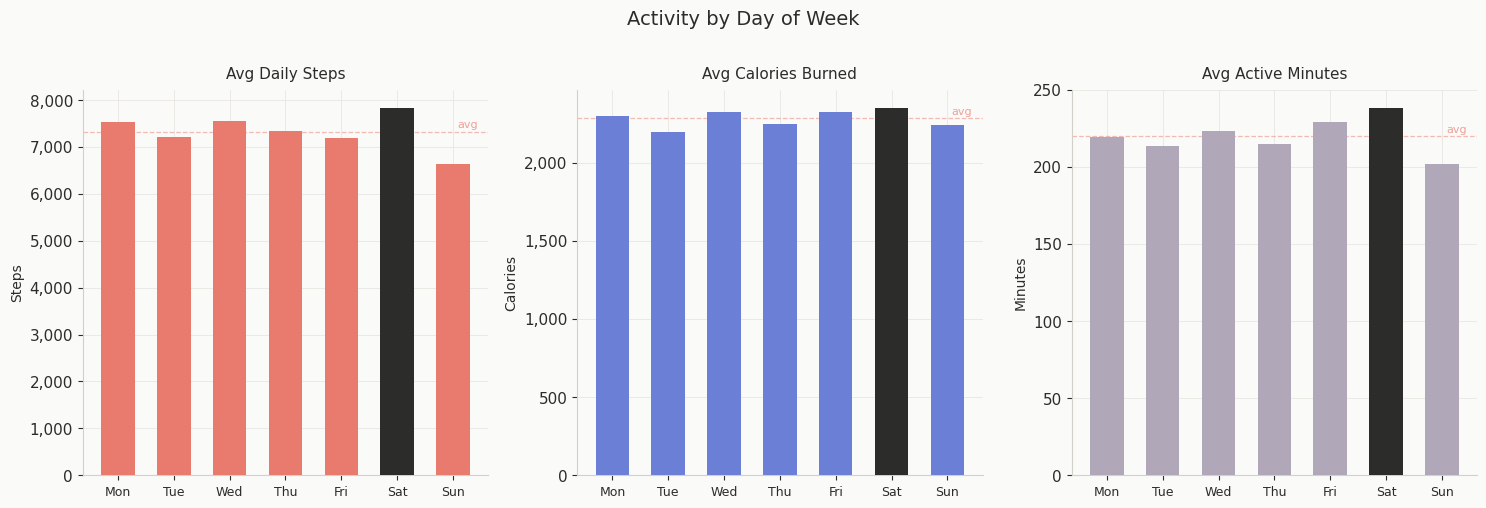

Avg steps by day:
  Monday        7,541  █████████████████████████
  Tuesday       7,212  ████████████████████████
  Wednesday     7,548  █████████████████████████
  Thursday      7,344  ████████████████████████
  Friday        7,188  ███████████████████████
  Saturday      7,831  ██████████████████████████
  Sunday        6,641  ██████████████████████

  Most active day:  Saturday (7,831 steps)
  Least active day: Sunday (6,641 steps)
  Difference:       1,190 steps

✓ Chart saved to Drive


In [15]:
DAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# ── Aggregate by day of week ──────────────────────────────────────────────────
steps_dow  = da.groupby('day_of_week')['total_steps'].mean().reindex(DAY_ORDER)
cal_dow    = da.groupby('day_of_week')['calories'].mean().reindex(DAY_ORDER)
active_dow = da.groupby('day_of_week')['total_active_minutes'].mean().reindex(DAY_ORDER)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Activity by Day of Week', fontsize=14, fontweight='500', y=1.01)

datasets   = [steps_dow,   cal_dow,              active_dow]
titles     = ['Avg Daily Steps', 'Avg Calories Burned', 'Avg Active Minutes']
ylabels    = ['Steps',       'Calories',           'Minutes']
bar_colors = [BRAND,         ACCENT,               NEUTRAL]

for ax, data, title, ylabel, color in zip(axes, datasets, titles, ylabels, bar_colors):
    # highlight max bar
    colors = [color if v != data.max() else TEXT for v in data.values]
    bars   = ax.bar(DAY_ORDER, data.values, color=colors, width=0.6, zorder=3)
    # average reference line
    ax.axhline(data.mean(), color=BRAND, linewidth=0.9,
               linestyle='--', alpha=0.5, zorder=2)
    ax.text(6.45, data.mean() * 1.012, 'avg',
            fontsize=8, color=BRAND, alpha=0.7, ha='right')
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(range(len(DAY_ORDER)))
    ax.set_xticklabels([d[:3] for d in DAY_ORDER], fontsize=9)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(f'{VIZ_PATH}/01_activity_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print numbers ─────────────────────────────────────────────────────────────
print('Avg steps by day:')
for day, val in steps_dow.items():
    bar = '█' * int(val / 300)
    print(f'  {day:<12} {val:>6,.0f}  {bar}')
print(f'\n  Most active day:  {steps_dow.idxmax()} ({steps_dow.max():,.0f} steps)')
print(f'  Least active day: {steps_dow.idxmin()} ({steps_dow.min():,.0f} steps)')
print(f'  Difference:       {steps_dow.max() - steps_dow.min():,.0f} steps')
print(f'\n✓ Chart saved to Drive')

**Finding 1:** Saturday is the most active day (7,831 avg steps)
and Sunday the least active (6,641 avg steps) — a difference of
1,190 steps. Weekdays cluster tightly between 7,100–7,550 steps
with Friday being the lowest weekday. Activity is consistently
below the CDC's 10,000-step target every single day of the week.

> **Leaf implication:** No single day hits the CDC target on
> average — this is not a weekend vs weekday problem, it is an
> every-day problem. Bellabeat should market Leaf's daily
> inactivity alerts as a 7-day solution, not just a weekend
> motivator. Low-activity days (Sunday and Friday) are the best
> days to send Bellabeat app challenges and push notifications.